# 01 - Setup, Dataset & Exploratory Data Analysis

**Track:** Movies — MovieLens *Latest Small* (`ml-latest-small`).

**Source:** GroupLens Research, https://grouplens.org/datasets/movielens/ . The *small* variant contains ~100k ratings from 610 users on ~9.7k movies. License: free for research/education (see `data/raw/ml-latest-small/README.txt`).

This notebook covers the first two stages of the project:
1. **Setup + dataset loading** (reusing `src/data_loading.py` so the same code is used everywhere).
2. **Exploratory Data Analysis (EDA)**: size, sparsity, rating distribution, user activity and item popularity, and the long-tail / popularity-bias picture that will matter when we evaluate recommenders later.

All figures are saved to `results/figures/` so they can be reused in the slide deck and final report.

In [1]:
import sys
from pathlib import Path

# Make the project root importable so we can reuse src/ modules from the notebook.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.data_loading import (
    load_ratings,
    load_items,
    describe_dataset,
    train_test_split_ratings,
)

FIG_DIR = config.RESULTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 110
print("Project root:", PROJECT_ROOT)

Project root: C:\python\Recomender_system\recommender_assignment_placeholders


## 1. Load the data

`load_ratings` / `load_items` read the MovieLens CSVs and validate that the expected columns exist. The default paths come from `src/config.py` (`data/raw/ratings.csv` and `data/raw/movies.csv`).

In [2]:
ratings = load_ratings()
items = load_items()

print("ratings:", ratings.shape)
display(ratings.head())
print("items:", items.shape)
display(items.head())

ratings: (100836, 4)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


items: (9742, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## 2. Summary statistics

`describe_dataset` prints the headline numbers (users, items, interactions, sparsity, rating distribution, most popular items) and returns them as a dict for reuse below.

In [3]:
stats = describe_dataset(ratings, items)

Dataset summary
Users:                 610
Items (rated):         9,724
Items (catalog):       9,742
Interactions:          100,836
Sparsity:              98.3000%
Density:               1.7000%
Ratings per user:      min=20, median=70, max=2698
Ratings per item:      min=1, median=3, max=329
Rating range:          0.5 - 5.0 (mean=3.50)

Rating distribution:
   0.5:   1,370 (1.4%)
   1.0:   2,811 (2.8%)
   1.5:   1,791 (1.8%)
   2.0:   7,551 (7.5%)
   2.5:   5,550 (5.5%)
   3.0:  20,047 (19.9%)
   3.5:  13,136 (13.0%)
   4.0:  26,818 (26.6%)
   4.5:   8,551 (8.5%)
   5.0:  13,211 (13.1%)

Most popular items (by number of ratings):
  Forrest Gump (1994) (329 ratings)
  Shawshank Redemption, The (1994) (317 ratings)
  Pulp Fiction (1994) (307 ratings)
  Silence of the Lambs, The (1991) (279 ratings)
  Matrix, The (1999) (278 ratings)
  Star Wars: Episode IV - A New Hope (1977) (251 ratings)
  Jurassic Park (1993) (238 ratings)
  Braveheart (1995) (237 ratings)
  Terminator 2: Judgment Da

**Reading the numbers.** The user-item matrix is ~98% empty (typical for recommenders), so memory-based methods must work on sparse data. Every user has rated at least 20 movies (a clean property of MovieLens), which means a per-user train/test split is feasible for all users. The rating scale is 0.5-5.0 and skews positive (mean ~3.5, mode at 4.0) — a *positivity bias* we should remember when defining "relevant" items for evaluation.

## 3. Rating distribution

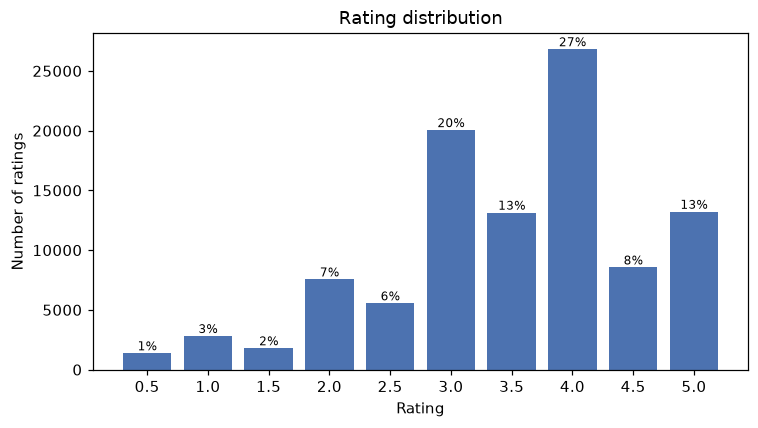

In [4]:
dist = stats["rating_distribution"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(dist.index.astype(str), dist.values, color="#4C72B0")
ax.set_title("Rating distribution")
ax.set_xlabel("Rating")
ax.set_ylabel("Number of ratings")
for x, y in zip(dist.index.astype(str), dist.values):
    ax.text(x, y, f"{y/len(ratings):.0%}", ha="center", va="bottom", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "rating_distribution.png", bbox_inches="tight")
plt.show()

## 4. User activity and item popularity

How many ratings does each user give, and how many ratings does each item receive? Both are heavily skewed — a few power users and a few blockbuster movies dominate.

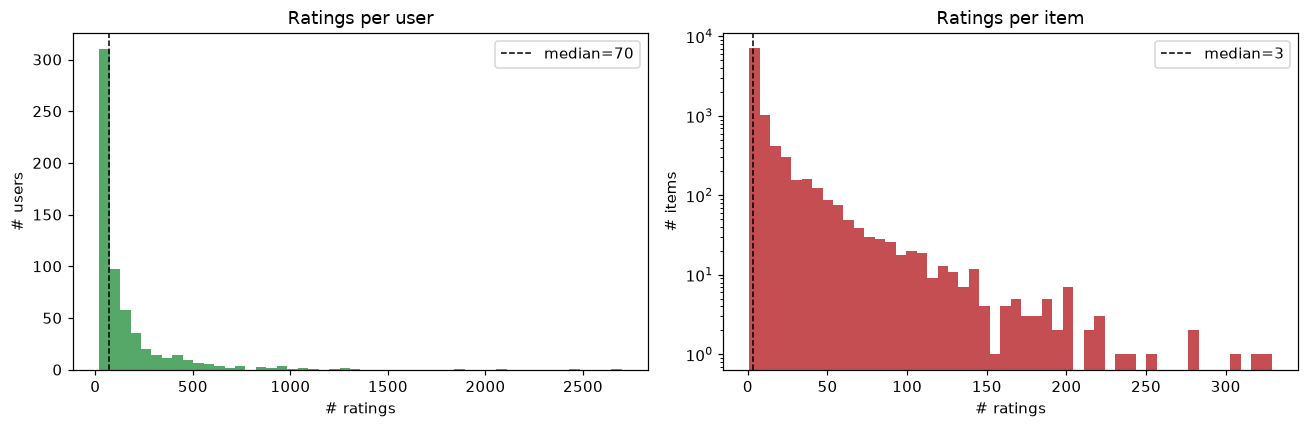

In [5]:
rpu = stats["ratings_per_user"]
rpi = stats["ratings_per_item"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(rpu.values, bins=50, color="#55A868")
axes[0].set_title("Ratings per user")
axes[0].set_xlabel("# ratings")
axes[0].set_ylabel("# users")
axes[0].axvline(rpu.median(), color="k", ls="--", lw=1, label=f"median={rpu.median():.0f}")
axes[0].legend()

axes[1].hist(rpi.values, bins=50, color="#C44E52")
axes[1].set_title("Ratings per item")
axes[1].set_xlabel("# ratings")
axes[1].set_ylabel("# items")
axes[1].axvline(rpi.median(), color="k", ls="--", lw=1, label=f"median={rpi.median():.0f}")
axes[1].set_yscale("log")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / "activity_distributions.png", bbox_inches="tight")
plt.show()

## 5. The long tail (popularity bias)

Sorting items by popularity shows the classic long tail: a small head of movies accounts for a large share of all ratings. This is exactly why a *most-popular* baseline is hard to beat on accuracy, and why we will later measure **catalog coverage** and **novelty** — accuracy alone would reward simply recommending the head.

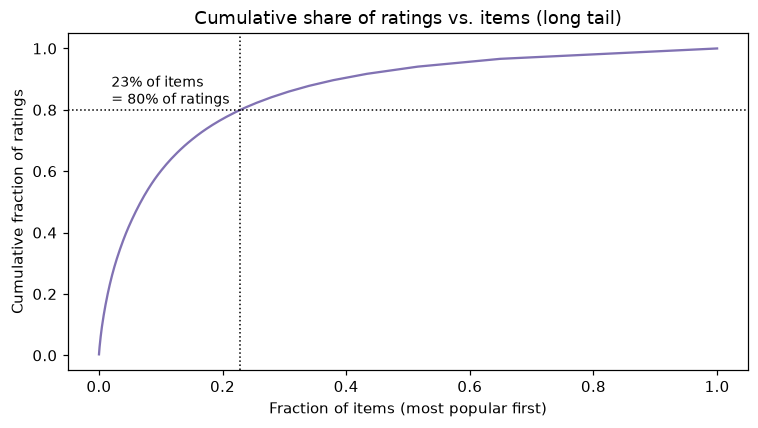

22.9% of the most popular movies account for 80% of all ratings.


In [6]:
pop_sorted = rpi.sort_values(ascending=False).reset_index(drop=True)
cum_share = pop_sorted.cumsum() / pop_sorted.sum()
frac_items_for_80 = (cum_share <= 0.8).sum() / len(pop_sorted)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, len(cum_share) + 1) / len(cum_share), cum_share.values, color="#8172B3")
ax.axhline(0.8, color="k", ls=":", lw=1)
ax.axvline(frac_items_for_80, color="k", ls=":", lw=1)
ax.set_title("Cumulative share of ratings vs. items (long tail)")
ax.set_xlabel("Fraction of items (most popular first)")
ax.set_ylabel("Cumulative fraction of ratings")
ax.text(0.02, 0.82, f"{frac_items_for_80:.0%} of items\n= 80% of ratings", fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "long_tail.png", bbox_inches="tight")
plt.show()

print(f"{frac_items_for_80:.1%} of the most popular movies account for 80% of all ratings.")

## 6. Most popular movies

In [7]:
top = stats["most_popular_items"].rename("n_ratings").to_frame()
top = top.merge(items.set_index(config.ITEM_COL)[config.TITLE_COL], left_index=True, right_index=True)
display(top[[config.TITLE_COL, "n_ratings"]])

,title,n_ratings
movieId,,
356,Forrest Gump (1994),329
318,"Shawshank Redemption, The (1994)",317
296,Pulp Fiction (1994),307
593,"Silence of the Lambs, The (1991)",279
2571,"Matrix, The (1999)",278
260,Star Wars: Episode IV - A New Hope (1977),251
480,Jurassic Park (1993),238
110,Braveheart (1995),237
589,Terminator 2: Judgment Day (1991),224


## 7. Genres

The `genres` column (pipe-separated) is the raw material for the content-based recommender. Here we just check the catalog-level distribution.

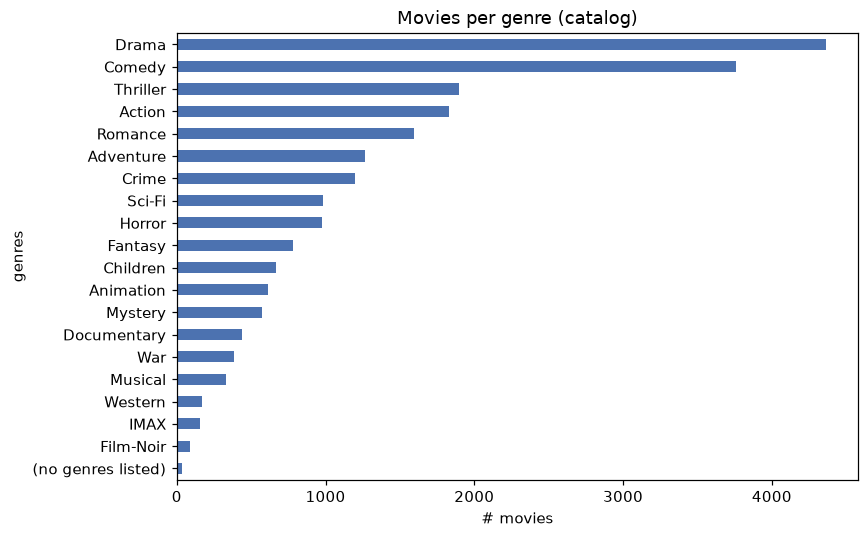

Movies tagged '(no genres listed)': 34


In [8]:
genre_counts = (
    items[config.GENRES_COL]
    .str.split("|")
    .explode()
    .value_counts()
)

fig, ax = plt.subplots(figsize=(8, 5))
genre_counts.sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set_title("Movies per genre (catalog)")
ax.set_xlabel("# movies")
fig.tight_layout()
fig.savefig(FIG_DIR / "genre_distribution.png", bbox_inches="tight")
plt.show()

print("Movies tagged '(no genres listed)':", int(genre_counts.get("(no genres listed)", 0)))

## 8. Train/test split sanity check

We use a per-user stratified split (`train_test_split_ratings`) so every user keeps ~80% of their history for training and ~20% as held-out test items for top-N evaluation. We confirm that all users appear in both sets.

In [9]:
train, test = train_test_split_ratings(ratings, test_size=0.2)
print("train:", train.shape, "| test:", test.shape)
print("users in train:", train[config.USER_COL].nunique(),
      "| users in test:", test[config.USER_COL].nunique(),
      "| total users:", ratings[config.USER_COL].nunique())

# How many test items are 'relevant' (rating >= 4.0)? This defines the ground truth
# we will use for Precision/Recall/NDCG in the evaluation notebook.
relevant_test = test[test[config.RATING_COL] >= 4.0]
print("\nTest interactions with rating >= 4.0 (relevant):",
      f"{len(relevant_test):,} ({len(relevant_test)/len(test):.0%} of test)")

train: (80668, 4) | test: (20168, 4)
users in train: 610 | users in test: 610 | total users: 610

Test interactions with rating >= 4.0 (relevant): 9,732 (48% of test)


## Takeaways for the rest of the project

- **Sparse (~98%)** matrix → expect cold-start and coverage challenges; memory-based CF must stay sparse.
- **Positivity bias** (mean ~3.5, mode 4.0) → define relevance as rating ≥ 4.0 for top-N evaluation.
- **Strong long tail / popularity bias** → a most-popular baseline will be a tough accuracy benchmark, so we must report beyond-accuracy metrics (coverage, novelty, diversity), not accuracy alone.
- **Every user has ≥20 ratings** → per-user stratified split works for all users.
- **Genres available for content-based** → next step is to vectorize them (TF-IDF) for the content-based recommender.

**Next notebook:** non-personalized baselines + the evaluation harness (`src/baselines.py`, `src/evaluation.py`).